In [47]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import display

In [29]:
df = pd.read_csv("D:\Data Analyst Agent\datasets\SampleSuperstore.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\anshj\AppData\Local\Temp\ipykernel_5708\3301785188.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\Data Analyst Agent\datasets\SampleSuperstore.csv")


In [30]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.7 MB


In [32]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [33]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [34]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

In [35]:
df.shape

(9994, 13)

In [36]:
df.columns.to_list()

['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Category',
 'Sub-Category',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [37]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [38]:
df.memory_usage(deep=True).sum()/1024**2

np.float64(1.7284059524536133)

In [39]:
missing = pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing %" : round(df.isnull().sum()*100, 2)
})

missing = missing[missing["Missing Count"] > 0]
missing

,Missing Count,Missing %


In [40]:
df.duplicated().sum()

np.int64(17)

In [ ]:

numerical_cols = df.select_dtypes(
    include = np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude = np.number
).columns.tolist()

numerical_cols

['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']

In [42]:
categorical_cols

['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Category',
 'Sub-Category']

In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [44]:
# skewness
from scipy.stats import skew
for col in numerical_cols:
    print(f"{col}: {round(skew(df[col].dropna()),2)}")

Postal Code: -0.13
Sales: 12.97
Quantity: 1.28
Discount: 1.68
Profit: 7.56


In [45]:
# IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) | (df[col] > upper)
    ]

    print(f"{col} : {len(outliers)} outliers")

Postal Code : 0 outliers
Sales : 1167 outliers
Quantity : 170 outliers
Discount : 856 outliers
Profit : 1881 outliers


In [48]:
corr = df[numerical_cols].corr()
display(corr)

,Postal Code,Sales,Quantity,Discount,Profit
Postal Code,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,-0.029961,0.479064,0.066253,-0.219487,1.000000


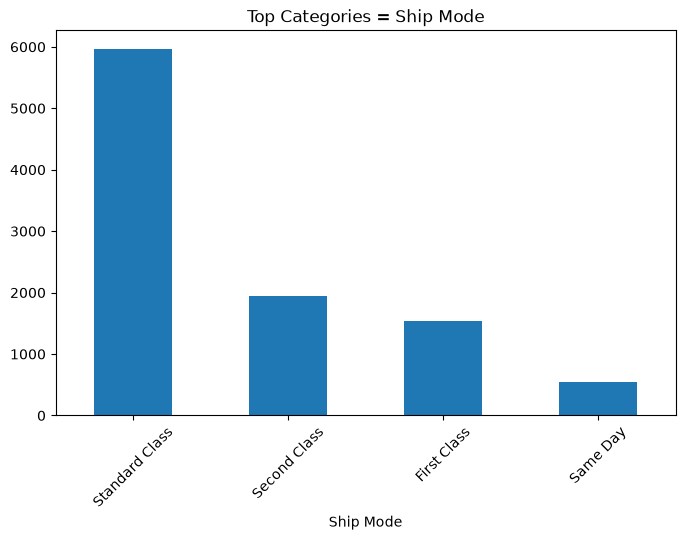

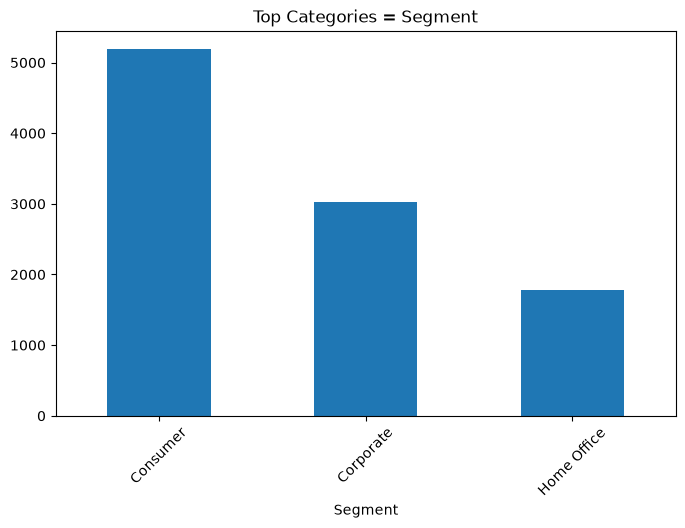

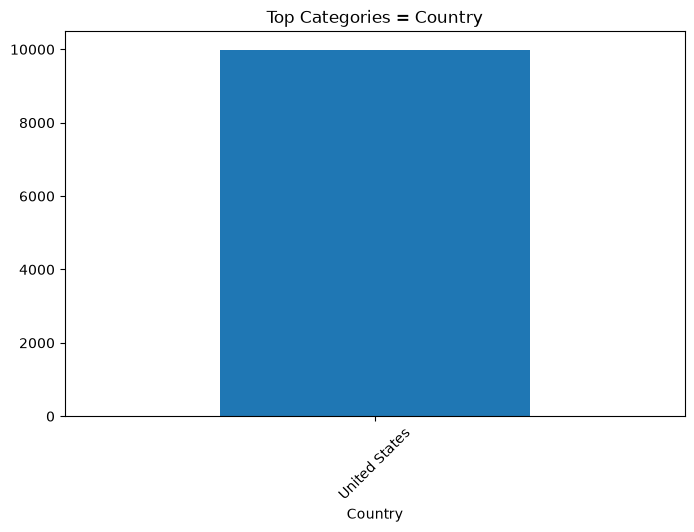

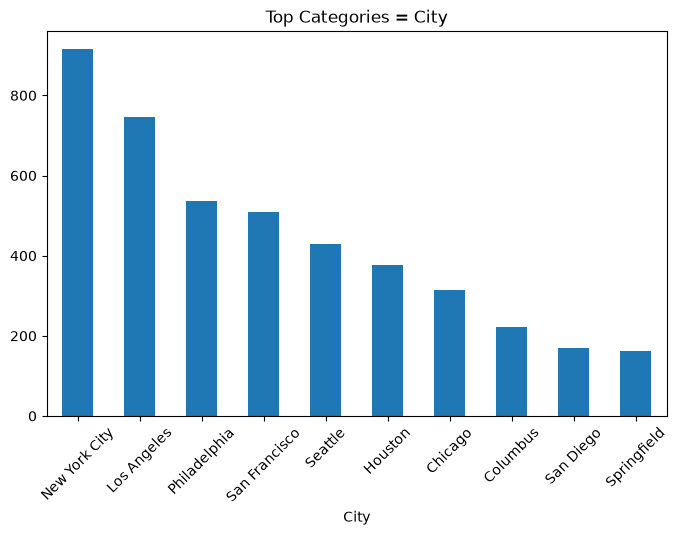

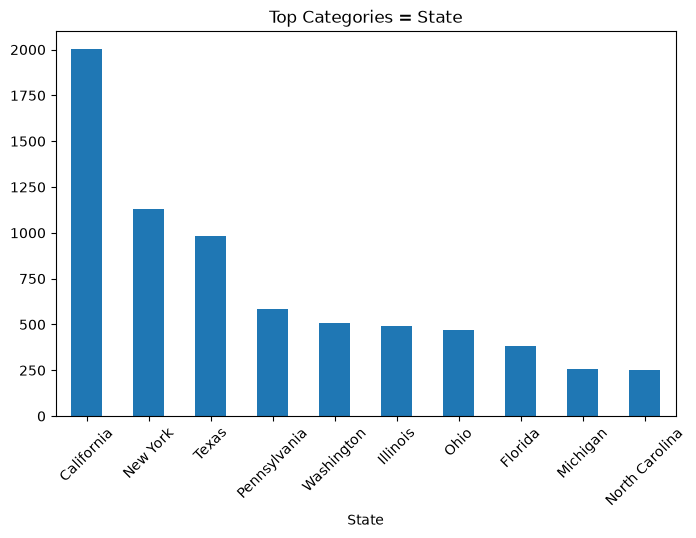

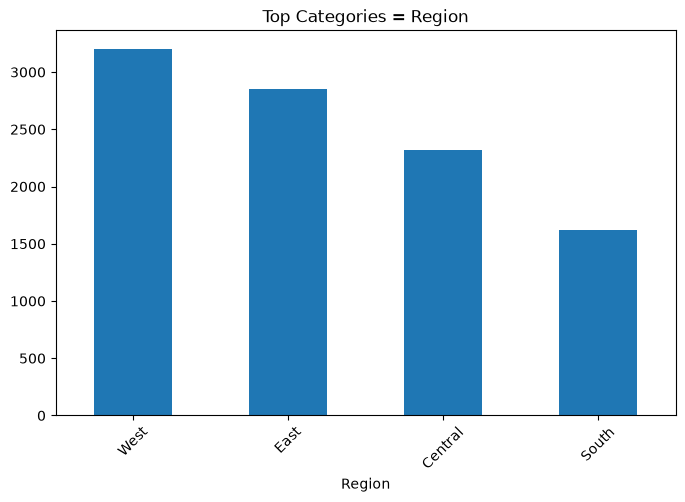

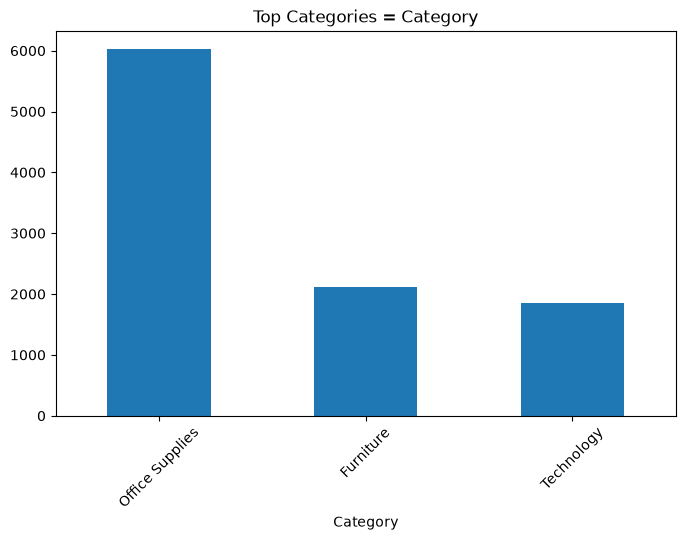

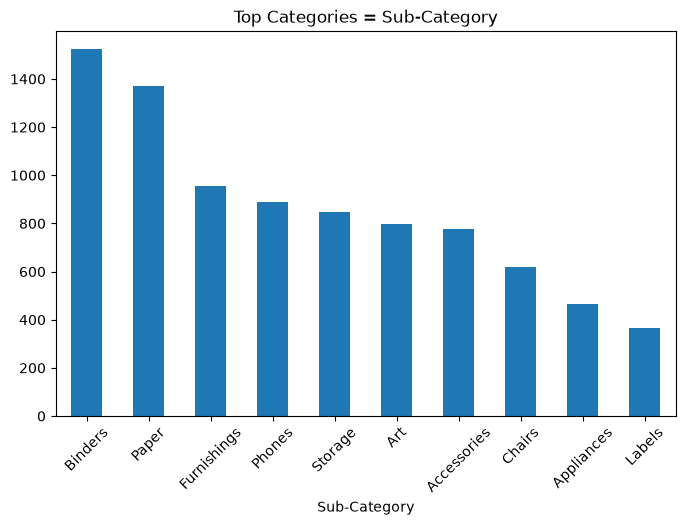

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    df[col].value_counts()\
        .head(10)\
        .plot(kind='bar')
    
    plt.title(f"Top Categories = {col}")
    plt.xticks(rotation=45)
    plt.show()

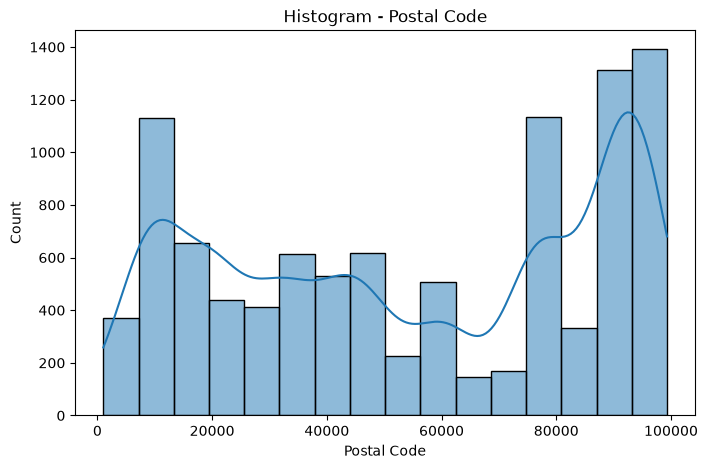

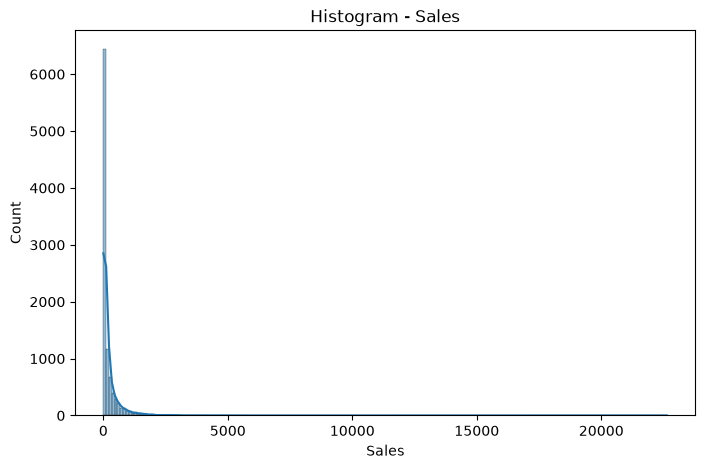

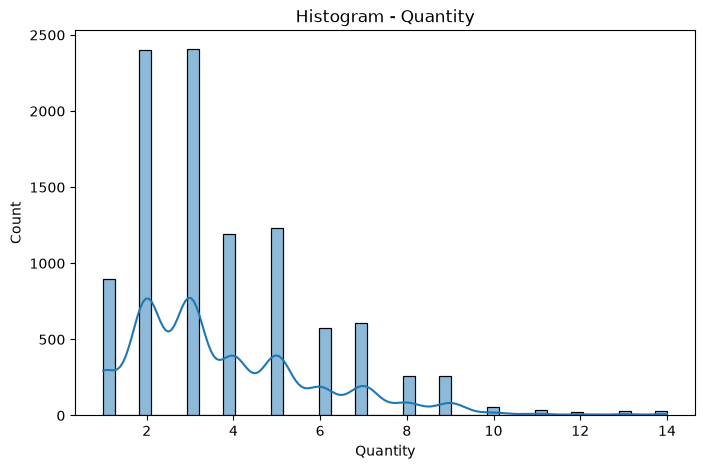

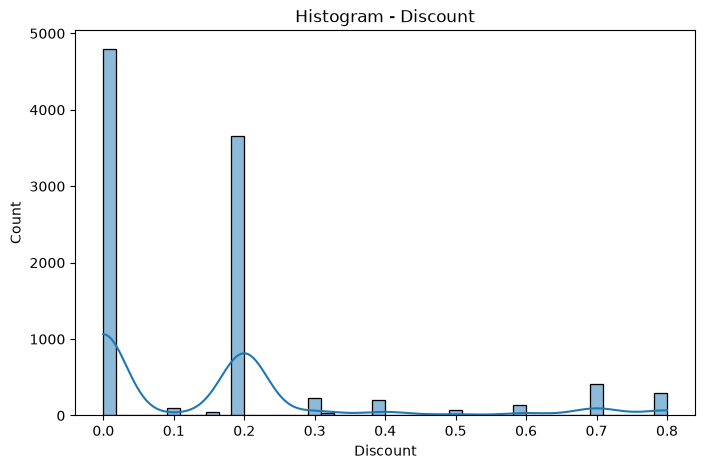

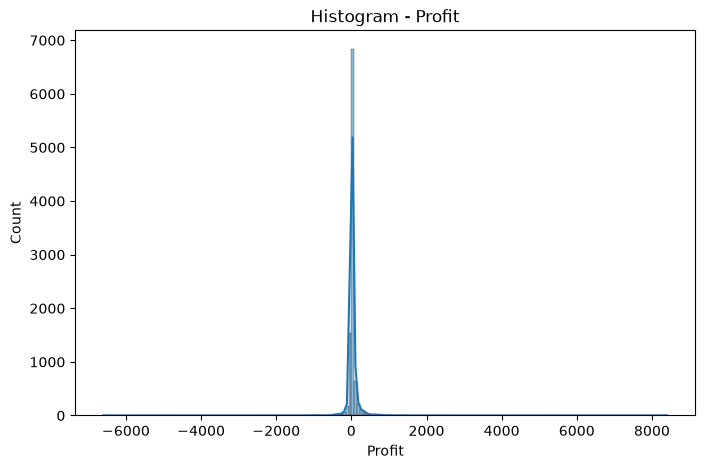

In [54]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Histogram - {col}")

    plt.show()

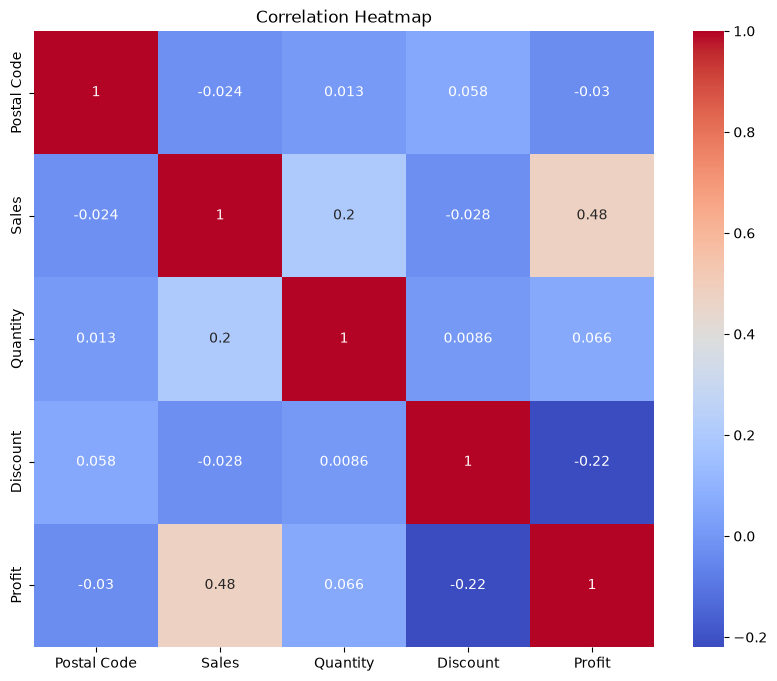

In [55]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()